In [1]:
import os
import sys
import re
import json
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

os.environ.setdefault("FLASH_ENV", "remote")


def find_repo_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "analysis" / "scripts").exists():
            return p

    fallback = Path("/home/mmanresa/glycine26")
    if (fallback / "analysis" / "scripts").exists():
        return fallback

    raise RuntimeError("Could not find repo root containing analysis/scripts")


repo_root = find_repo_root()
scripts_dir = repo_root / "analysis" / "scripts"
sys.path.insert(0, str(scripts_dir))

import config
from compute_aggregates import load_aggregates

AggregatesData = load_aggregates.__globals__["AggregatesData"]


def load_aggregates_etof(path):
    """
    Lightweight aggregate loader.

    Used here only for metadata, source-H5 paths, GMD edges, and TOF edges.
    Large covariance matrices are deliberately skipped.
    """
    path = Path(path)

    with h5py.File(path, "r") as f:
        meta = {}
        for k in f.attrs:
            v = f.attrs[k]
            meta[k] = v.tolist() if isinstance(v, np.ndarray) else v

        def _opt(k):
            return f[k][:] if k in f else None

        return AggregatesData(
            G=f["G"][:],
            GtG=_opt("GtG"),
            n_per_bin=f["n_per_bin"][:],
            gmd_edges=f["gmd_edges"][:],

            D=_opt("D"),
            tof_edges=_opt("tof_edges"),

            DtD=None,
            DtG=None,

            A=None,
            AtA=None,
            AtD=None,
            AtG=None,
            vls_pixels=_opt("vls_pixels"),
            background=_opt("background"),

            C=None,
            CtC=None,
            DtC=None,
            CtG=None,
            ion_tof_edges=_opt("ion_tof_edges"),

            z_edges=_opt("z_edges"),
            nominal_energies=_opt("nominal_energies"),
            metadata=meta,
        )


print("repo_root   :", repo_root)
print("FLASH_ENV   :", os.environ.get("FLASH_ENV"))
print("COMBINED_DIR:", config.COMBINED_DIR)

repo_root   : /home/mmanresa/glycine26
FLASH_ENV   : remote
COMBINED_DIR: /asap3/flash/gpfs/fl24/2026/data/11022188/processed/combined


In [2]:
AGG_DIR = Path(config.COMBINED_DIR)
GLOB = "glycine_WL_scan_*eV_aggregates_etof1.h5"

MIN_ENERGY = None
MAX_ENERGY = None

# Optional split:
#   None       -> all wavelength-scan aggregate files
#   "floating" -> files like 270.0eV, 270.5eV
#   "integer"  -> files like 279eV, 280eV
SCAN_FAMILY = "floating"

ENERGY_RE = re.compile(
    r"^glycine_WL_scan_(\d+(?:\.\d+)?)eV_aggregates_etof1$"
)


def energy_from_name(path):
    m = ENERGY_RE.search(Path(path).stem)
    if m is None:
        raise ValueError(f"Could not parse photon energy from {path.name}")
    return float(m.group(1))


def scan_family_from_filename(path):
    m = ENERGY_RE.search(Path(path).stem)
    if m is None:
        return "unknown"
    token = m.group(1)
    return "floating" if "." in token else "integer"


files = []
for p in sorted(AGG_DIR.glob(GLOB)):
    e = energy_from_name(p)
    fam = scan_family_from_filename(p)

    if SCAN_FAMILY is not None and fam != SCAN_FAMILY:
        continue
    if MIN_ENERGY is not None and e < MIN_ENERGY:
        continue
    if MAX_ENERGY is not None and e > MAX_ENERGY:
        continue

    files.append((p, e, fam))

files = sorted(files, key=lambda x: (x[1], x[0].name))

print(f"{len(files)} aggregate files:")
for p, e, fam in files:
    print(f"  {e:8.2f} eV  {fam:8s}  {p.name}")

if not files:
    raise FileNotFoundError(f"No files matched {AGG_DIR / GLOB}")

27 aggregate files:
    270.00 eV  floating  glycine_WL_scan_270.0eV_aggregates_etof1.h5
    270.50 eV  floating  glycine_WL_scan_270.5eV_aggregates_etof1.h5
    271.00 eV  floating  glycine_WL_scan_271.0eV_aggregates_etof1.h5
    271.50 eV  floating  glycine_WL_scan_271.5eV_aggregates_etof1.h5
    272.00 eV  floating  glycine_WL_scan_272.0eV_aggregates_etof1.h5
    272.50 eV  floating  glycine_WL_scan_272.5eV_aggregates_etof1.h5
    273.00 eV  floating  glycine_WL_scan_273.0eV_aggregates_etof1.h5
    273.50 eV  floating  glycine_WL_scan_273.5eV_aggregates_etof1.h5
    274.00 eV  floating  glycine_WL_scan_274.0eV_aggregates_etof1.h5
    274.50 eV  floating  glycine_WL_scan_274.5eV_aggregates_etof1.h5
    275.00 eV  floating  glycine_WL_scan_275.0eV_aggregates_etof1.h5
    275.50 eV  floating  glycine_WL_scan_275.5eV_aggregates_etof1.h5
    276.00 eV  floating  glycine_WL_scan_276.0eV_aggregates_etof1.h5
    276.50 eV  floating  glycine_WL_scan_276.5eV_aggregates_etof1.h5
    277.00 eV 

In [3]:
CALIB_PATH = Path(config.COMBINED_DIR).parent / "Calibrations" / "etof_energy_calibration_t0_scan.json"

with open(CALIB_PATH, "r", encoding="utf-8") as fh:
    calib = json.load(fh)

best_t0 = calib["t0_tof_units"]
best_slope = calib["slope_eV_tof_unit2"]
best_E0 = calib["E0_eV"]


def tof_to_ke(t):
    t = np.asarray(t, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        ke = best_slope / (t - best_t0) ** 2 + best_E0
    return np.where(t > best_t0, ke, np.nan)


def half_step_edges(x):
    x = np.asarray(x, dtype=float)
    if x.size == 1:
        return np.array([x[0] - 0.5, x[0] + 0.5])
    mid = 0.5 * (x[:-1] + x[1:])
    return np.concatenate([[2 * x[0] - mid[0]], mid, [2 * x[-1] - mid[-1]]])


def robust_limits(a, p_lo=1, p_hi=99.5):
    finite = np.asarray(a)[np.isfinite(a)]
    if finite.size == 0:
        return 0.0, 1.0
    return float(np.nanpercentile(finite, p_lo)), float(np.nanpercentile(finite, p_hi))


def tof_map_to_ke_density(tof_edges, tof_map, tof_range):
    """
    Slice TOF-binned map, convert x-axis to calibrated KE, and divide by KE-bin width.

    Input units: counts / uJ / TOF bin
    Output units: counts / uJ / eV
    """
    tof_edges = np.asarray(tof_edges, dtype=float)
    tof_map = np.asarray(tof_map, dtype=float)

    tof_cent = 0.5 * (tof_edges[:-1] + tof_edges[1:])
    mask = np.ones_like(tof_cent, dtype=bool)

    if tof_range[0] is not None:
        mask &= tof_cent >= tof_range[0]
    if tof_range[1] is not None:
        mask &= tof_cent <= tof_range[1]

    idx = np.where(mask)[0]
    if idx.size == 0:
        raise ValueError(f"No TOF bins inside TOF_RANGE={tof_range}")

    lo = int(idx[0])
    hi = int(idx[-1]) + 1

    data = tof_map[..., lo:hi]
    ke_edges = tof_to_ke(tof_edges[lo:hi + 1])

    if not np.all(np.isfinite(ke_edges)):
        raise ValueError("Some KE edges are NaN. Choose TOF_RANGE fully above t0.")

    ke_widths = np.abs(np.diff(ke_edges))
    with np.errstate(invalid="ignore", divide="ignore"):
        data = data / ke_widths

    if ke_edges[0] > ke_edges[-1]:
        ke_edges = ke_edges[::-1]
        data = data[..., ::-1]

    return ke_edges, data


print("Loaded eTOF calibration:")
print(f"  {CALIB_PATH}")
print(f"  t0    = {best_t0:.6f}")
print(f"  slope = {best_slope:.6e}")
print(f"  E0    = {best_E0:.6f}")

Loaded eTOF calibration:
  /asap3/flash/gpfs/fl24/2026/data/11022188/processed/Calibrations/etof_energy_calibration_t0_scan.json
  t0    = 70.317117
  slope = 1.726561e+08
  E0    = -32.015747


In [4]:
HIGH_GMD_RANGE = (6.0, 12.0)

TOF_RANGE = (800, 1100)
KE_XLIM = (160, 280)

CHUNK_TRAINS = 1000
MIN_SHOTS = 200
MIN_SUM_GMD = 100.0


def keep_mask_like_compute_aggregates_from_h5(f, trim_start=0, trim_end=0):
    if "between_tdc_files" not in f:
        return np.ones(f["gmd"].shape[0], dtype=bool)

    btf = f["between_tdc_files"][:].astype(bool)
    good_pos = np.where(~btf)[0]

    if trim_end > 0:
        good_pos = good_pos[trim_start:-trim_end]
    else:
        good_pos = good_pos[trim_start:]

    keep = np.zeros(btf.shape[0], dtype=bool)
    keep[good_pos] = True
    return keep


def source_h5_from_aggregate(path):
    agg = load_aggregates_etof(path)
    source_h5 = Path(agg.metadata.get("input_h5", ""))

    if not source_h5.exists():
        raise FileNotFoundError(f"{path.name}: source H5 not found: {source_h5}")

    return source_h5, agg


def shot_resolved_gmd_spectrum(
    source_h5,
    gmd_range,
    tof_edges,
    *,
    trim_start=0,
    trim_end=0,
    chunk_trains=1000,
):
    """
    Build S(E) = sum N(E) / sum GMD directly from shot-resolved H5.

    Returns counts/uJ per original TOF bin.
    """
    gmd_lo, gmd_hi = gmd_range

    total_counts = np.zeros(len(tof_edges) - 1, dtype=np.float64)
    total_gmd = 0.0
    total_shots = 0
    total_hits = 0

    with h5py.File(source_h5, "r") as f:
        keep = keep_mask_like_compute_aggregates_from_h5(
            f,
            trim_start=trim_start,
            trim_end=trim_end,
        )

        n_trains = f["gmd"].shape[0]
        max_slots = f["tofs_e"].shape[-1]
        saturated_shots = 0

        for s in range(0, n_trains, chunk_trains):
            e = min(s + chunk_trains, n_trains)
            row_keep = keep[s:e]

            if not row_keep.any():
                continue

            gmd = f["gmd"][s:e][row_keep]
            tofs = f["tofs_e"][s:e][row_keep]

            gmd_flat = gmd.ravel()
            tofs_flat = tofs.reshape(-1, tofs.shape[-1])

            shot_sel = (
                np.isfinite(gmd_flat)
                & (gmd_flat >= gmd_lo)
                & (gmd_flat < gmd_hi)
            )

            if not shot_sel.any():
                continue

            selected_tofs = tofs_flat[shot_sel]
            hits = selected_tofs.ravel()
            hits = hits[hits > 0]

            hist, _ = np.histogram(hits, bins=tof_edges)

            total_counts += hist.astype(np.float64)
            total_gmd += float(np.nansum(gmd_flat[shot_sel]))
            total_shots += int(np.count_nonzero(shot_sel))
            total_hits += int(hits.size)
            saturated_shots += int(np.count_nonzero(np.count_nonzero(selected_tofs > 0, axis=1) >= max_slots))

    with np.errstate(invalid="ignore", divide="ignore"):
        spectrum = total_counts / total_gmd

    spectrum[~np.isfinite(spectrum)] = np.nan

    return {
        "spectrum": spectrum,
        "counts": total_counts,
        "sum_gmd": total_gmd,
        "shots": total_shots,
        "hits": total_hits,
        "saturated_shots": saturated_shots,
        "gmd_range": gmd_range,
    }

In [5]:
high_rows = []
tof_edges_ref = None

for agg_path, energy, fam in files:
    print(f"Processing {energy:8.3f} eV  {fam:8s}  {agg_path.name}")

    try:
        source_h5, agg = source_h5_from_aggregate(agg_path)
    except Exception as exc:
        print(f"  skipped: {exc}")
        continue

    tof_edges = np.asarray(agg.tof_edges, dtype=float)

    if tof_edges_ref is None:
        tof_edges_ref = tof_edges
    elif not np.array_equal(tof_edges_ref, tof_edges):
        print("  skipped: TOF edges mismatch")
        continue

    trim_start = int(agg.metadata.get("trim_start", 0))
    trim_end = int(agg.metadata.get("trim_end", 0))

    high = shot_resolved_gmd_spectrum(
        source_h5,
        HIGH_GMD_RANGE,
        tof_edges,
        trim_start=trim_start,
        trim_end=trim_end,
        chunk_trains=CHUNK_TRAINS,
    )

    usable = high["shots"] >= MIN_SHOTS and high["sum_gmd"] >= MIN_SUM_GMD

    high_rows.append({
        "energy": float(energy),
        "family": fam,
        "agg_path": agg_path,
        "source_h5": source_h5,
        "tof_edges": tof_edges,
        "high": high,
        "usable": usable,
    })

    hits_per_gmd = high["hits"] / high["sum_gmd"] if high["sum_gmd"] > 0 else np.nan
    hits_per_shot = high["hits"] / high["shots"] if high["shots"] > 0 else np.nan
    sat_frac = high["saturated_shots"] / high["shots"] if high["shots"] > 0 else np.nan

    print(
        f"  usable={usable}  "
        f"shots={high['shots']:8d}  "
        f"sumGMD={high['sum_gmd']:10.4g}  "
        f"hits/shot={hits_per_shot:9.4g}  "
        f"hits/GMD={hits_per_gmd:9.4g}  "
        f"slot-filled frac={sat_frac:.3g}"
    )

print()
print(f"Built {len(high_rows)} high-GMD rows")
print(f"Usable rows: {sum(r['usable'] for r in high_rows)}")

Processing  270.000 eV  floating  glycine_WL_scan_270.0eV_aggregates_etof1.h5
  usable=True  shots=   69688  sumGMD= 5.936e+05  hits/shot=    10.46  hits/GMD=    1.228  slot-filled frac=1.43e-05
Processing  270.500 eV  floating  glycine_WL_scan_270.5eV_aggregates_etof1.h5
  usable=True  shots=   91341  sumGMD=  7.73e+05  hits/shot=    9.619  hits/GMD=    1.137  slot-filled frac=0
Processing  271.000 eV  floating  glycine_WL_scan_271.0eV_aggregates_etof1.h5
  usable=True  shots=   79812  sumGMD= 6.817e+05  hits/shot=    9.986  hits/GMD=    1.169  slot-filled frac=1.25e-05
Processing  271.500 eV  floating  glycine_WL_scan_271.5eV_aggregates_etof1.h5
  usable=True  shots=   84308  sumGMD= 7.153e+05  hits/shot=    9.703  hits/GMD=    1.144  slot-filled frac=4.74e-05
Processing  272.000 eV  floating  glycine_WL_scan_272.0eV_aggregates_etof1.h5
  usable=True  shots=   64045  sumGMD= 5.375e+05  hits/shot=    9.773  hits/GMD=    1.164  slot-filled frac=0
Processing  272.500 eV  floating  glyci

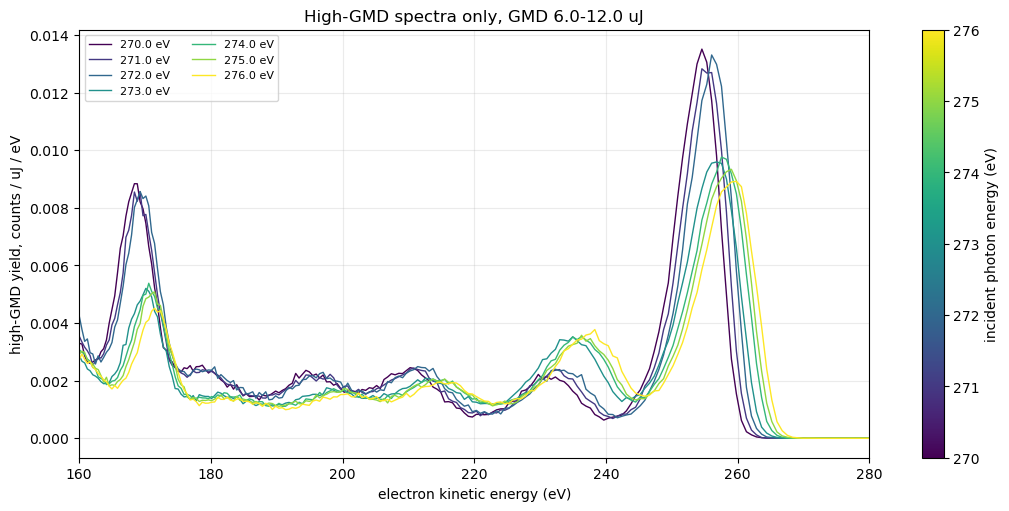

In [6]:
ENERGIES_TO_PLOT = [270, 271, 272, 273, 274, 275, 276]
USE_ONLY_USABLE = True

rows_available = [r for r in high_rows if r["usable"] or not USE_ONLY_USABLE]
available_e = np.array([r["energy"] for r in rows_available], dtype=float)

selected_rows = []
for target_e in ENERGIES_TO_PLOT:
    i = int(np.nanargmin(np.abs(available_e - target_e)))
    row = rows_available[i]

    if abs(row["energy"] - target_e) > 0.3:
        print(f"Skipping requested {target_e:.2f} eV; nearest is {row['energy']:.2f} eV")
        continue

    selected_rows.append(row)

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)

cmap = plt.get_cmap("viridis")
norm = plt.Normalize(
    vmin=min(r["energy"] for r in selected_rows),
    vmax=max(r["energy"] for r in selected_rows),
)

for r in selected_rows:
    ke_edges, y_ke = tof_map_to_ke_density(
        r["tof_edges"],
        r["high"]["spectrum"][None, :],
        TOF_RANGE,
    )

    ke_cent = 0.5 * (ke_edges[:-1] + ke_edges[1:])
    y = y_ke[0]

    ax.plot(
        ke_cent,
        y,
        lw=1.0,
        color=cmap(norm(r["energy"])),
        label=f"{r['energy']:.1f} eV",
    )

ax.set_xlabel("electron kinetic energy (eV)")
ax.set_ylabel("high-GMD yield, counts / uJ / eV")
ax.set_title(f"High-GMD spectra only, GMD {HIGH_GMD_RANGE[0]}-{HIGH_GMD_RANGE[1]} uJ")
ax.grid(alpha=0.25)

if KE_XLIM is not None:
    ax.set_xlim(KE_XLIM)

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("incident photon energy (eV)")

ax.legend(fontsize=8, ncols=2)
plt.show()

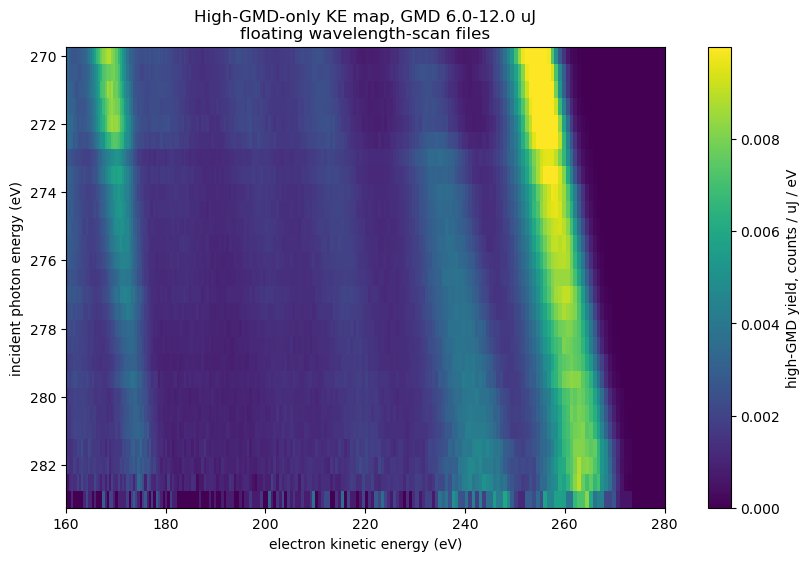

Rows in high-GMD-only map:
   270.000 eV  shots=   69688  sumGMD= 5.936e+05  hits/shot=    10.46  hits/GMD=    1.228  glycine_WL_scan_270.0eV_aggregates_etof1.h5
   270.500 eV  shots=   91341  sumGMD=  7.73e+05  hits/shot=    9.619  hits/GMD=    1.137  glycine_WL_scan_270.5eV_aggregates_etof1.h5
   271.000 eV  shots=   79812  sumGMD= 6.817e+05  hits/shot=    9.986  hits/GMD=    1.169  glycine_WL_scan_271.0eV_aggregates_etof1.h5
   271.500 eV  shots=   84308  sumGMD= 7.153e+05  hits/shot=    9.703  hits/GMD=    1.144  glycine_WL_scan_271.5eV_aggregates_etof1.h5
   272.000 eV  shots=   64045  sumGMD= 5.375e+05  hits/shot=    9.773  hits/GMD=    1.164  glycine_WL_scan_272.0eV_aggregates_etof1.h5
   272.500 eV  shots=   63971  sumGMD= 5.334e+05  hits/shot=    8.702  hits/GMD=    1.044  glycine_WL_scan_272.5eV_aggregates_etof1.h5
   273.000 eV  shots=  111626  sumGMD= 9.613e+05  hits/shot=        7  hits/GMD=   0.8129  glycine_WL_scan_273.0eV_aggregates_etof1.h5
   273.500 eV  shots=  10182

In [7]:
USE_ONLY_USABLE = True
VMIN = None
VMAX = None

rows_map = [r for r in high_rows if r["usable"] or not USE_ONLY_USABLE]
rows_map = sorted(rows_map, key=lambda r: (r["energy"], Path(r["agg_path"]).name))

energies_map = np.array([r["energy"] for r in rows_map], dtype=float)
high_map_tof = np.vstack([r["high"]["spectrum"] for r in rows_map])

ke_edges_map, high_map_ke = tof_map_to_ke_density(
    tof_edges_ref,
    high_map_tof,
    TOF_RANGE,
)

e_edges_map = half_step_edges(energies_map)

vmin_auto, vmax_auto = robust_limits(high_map_ke, p_lo=1, p_hi=99.5)
vmin = vmin_auto if VMIN is None else VMIN
vmax = vmax_auto if VMAX is None else VMAX

fig, ax = plt.subplots(figsize=(8, 5.5), constrained_layout=True)

pcm = ax.pcolormesh(
    ke_edges_map,
    e_edges_map,
    high_map_ke,
    shading="auto",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
)

fig.colorbar(pcm, ax=ax, label="high-GMD yield, counts / uJ / eV")

ax.set_xlabel("electron kinetic energy (eV)")
ax.set_ylabel("incident photon energy (eV)")
ax.set_title(
    f"High-GMD-only KE map, GMD {HIGH_GMD_RANGE[0]}-{HIGH_GMD_RANGE[1]} uJ\n"
    f"{SCAN_FAMILY if SCAN_FAMILY is not None else 'all'} wavelength-scan files"
)

if KE_XLIM is not None:
    ax.set_xlim(KE_XLIM)

ax.set_ylim(np.nanmax(e_edges_map), np.nanmin(e_edges_map))

plt.show()

print("Rows in high-GMD-only map:")
for r in rows_map:
    h = r["high"]
    hits_per_gmd = h["hits"] / h["sum_gmd"] if h["sum_gmd"] > 0 else np.nan
    hits_per_shot = h["hits"] / h["shots"] if h["shots"] > 0 else np.nan
    print(
        f"  {r['energy']:8.3f} eV  "
        f"shots={h['shots']:8d}  "
        f"sumGMD={h['sum_gmd']:10.4g}  "
        f"hits/shot={hits_per_shot:9.4g}  "
        f"hits/GMD={hits_per_gmd:9.4g}  "
        f"{Path(r['agg_path']).name}"
    )

In [8]:
# Edit HIGH_GMD_RANGE in Cell 4, then rerun Cells 5-7.
# Suggested checks:
#   (3.0, 6.0)
#   (6.0, 12.0)
#   (12.0, 24.0)
#   (6.0, 24.0)

print("Current high-GMD range:", HIGH_GMD_RANGE)
print("To test another range, change HIGH_GMD_RANGE in Cell 4 and rerun Cells 5-7.")

Current high-GMD range: (6.0, 12.0)
To test another range, change HIGH_GMD_RANGE in Cell 4 and rerun Cells 5-7.


Requested incident energy: 274.000 eV
Using nearest file       : 274.000 eV
Aggregate file           : glycine_WL_scan_274.0eV_aggregates_etof1.h5
Source H5                : /asap3/flash/gpfs/fl24/2026/data/11022188/processed/combined/glycine_WL_scan_274.0eV.h5
Trim start/end           : 3, 3


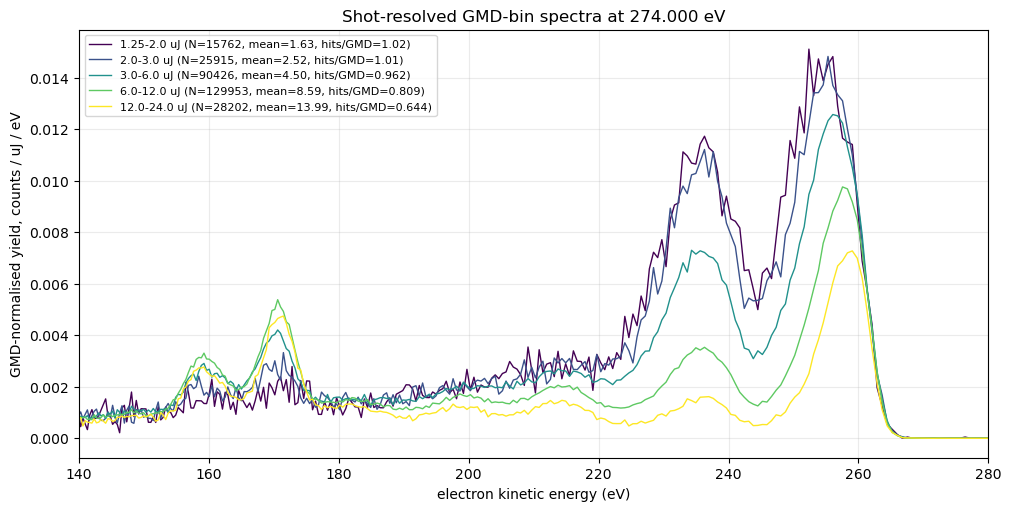

In [12]:
# --- Shot-resolved spectra for several GMD bins at one incident energy ---

PLOT_ENERGY_EV = 274.0

GMD_RANGES_TO_PLOT = [
    # (0.5, 1.25),
    (1.25, 2.0),
    (2.0, 3.0),
    (3.0, 6.0),
    (6.0, 12.0),
    (12.0, 24.0),
]

TOF_RANGE = (800, 1100)
KE_XLIM = (140, 280)

# Find nearest aggregate file only to locate the corresponding source H5 and TOF edges.
available_e = np.array([e for _, e, *_ in files], dtype=float)
i = int(np.nanargmin(np.abs(available_e - PLOT_ENERGY_EV)))

file_tuple = files[i]
agg_path = file_tuple[0]
energy = file_tuple[1]

print(f"Requested incident energy: {PLOT_ENERGY_EV:.3f} eV")
print(f"Using nearest file       : {energy:.3f} eV")
print(f"Aggregate file           : {agg_path.name}")

source_h5, agg = source_h5_from_aggregate(agg_path)
tof_edges = np.asarray(agg.tof_edges, dtype=float)

trim_start = int(agg.metadata.get("trim_start", 0))
trim_end = int(agg.metadata.get("trim_end", 0))

print(f"Source H5                : {source_h5}")
print(f"Trim start/end           : {trim_start}, {trim_end}")

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)

cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, len(GMD_RANGES_TO_PLOT)))

for color, gmd_range in zip(colors, GMD_RANGES_TO_PLOT):
    result = shot_resolved_gmd_spectrum(
        source_h5,
        gmd_range,
        tof_edges,
        trim_start=trim_start,
        trim_end=trim_end,
        chunk_trains=CHUNK_TRAINS,
    )

    ke_edges, spec_ke = tof_map_to_ke_density(
        tof_edges,
        result["spectrum"][None, :],
        TOF_RANGE,
    )

    ke_cent = 0.5 * (ke_edges[:-1] + ke_edges[1:])
    y = spec_ke[0]

    mean_gmd = result["sum_gmd"] / result["shots"] if result["shots"] > 0 else np.nan
    hits_per_gmd = result["hits"] / result["sum_gmd"] if result["sum_gmd"] > 0 else np.nan

    label = (
        f"{gmd_range[0]}-{gmd_range[1]} uJ "
        f"(N={result['shots']}, mean={mean_gmd:.2f}, hits/GMD={hits_per_gmd:.3g})"
    )

    ax.plot(ke_cent, y, lw=1.0, color=color, label=label)

ax.set_xlabel("electron kinetic energy (eV)")
ax.set_ylabel("GMD-normalised yield, counts / uJ / eV")
ax.set_title(f"Shot-resolved GMD-bin spectra at {energy:.3f} eV")
ax.grid(alpha=0.25)
ax.legend(fontsize=8)

if KE_XLIM is not None:
    ax.set_xlim(KE_XLIM)

plt.show()

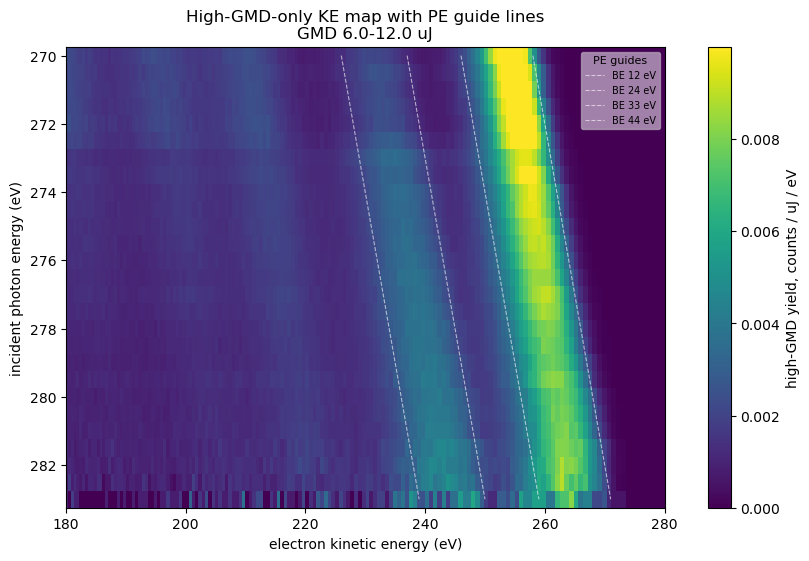

In [30]:
# --- High-GMD map with PE-like diagonal guides ------------------------

USE_ONLY_USABLE = True

# Adjust these binding energies / labels to the orbitals/features you care about.
# Lines are E_kin = hnu - E_binding.
PE_GUIDES = [
    (12.0, "BE 16 eV"),
    # (20.0, "BE 20 eV"),
    (24.0, "BE 24 eV"),
    # (30.0, "BE 30 eV"),
    (33.0, "BE 33 eV"),
    # (40.0, "BE 40 eV"),
    (44.0, "BE 44 eV"),
    # (50.0, "BE 50 eV"),
]

LABEL_GUIDES = {20.0, 30.0, 40.0, 50.0}  # label only these
LABEL_ENERGY_FRACTIONS = {
    20.0: 0.20,
    30.0: 0.40,
    40.0: 0.60,
    50.0: 0.80,
}

TOF_RANGE = (800, 1100)
KE_XLIM = (180, 280)

VMIN = None
VMAX = None

rows_map = [r for r in high_rows if r["usable"] or not USE_ONLY_USABLE]
rows_map = sorted(rows_map, key=lambda r: (r["energy"], Path(r["agg_path"]).name))

energies_map = np.array([r["energy"] for r in rows_map], dtype=float)
high_map_tof = np.vstack([r["high"]["spectrum"] for r in rows_map])

ke_edges_map, high_map_ke = tof_map_to_ke_density(
    tof_edges_ref,
    high_map_tof,
    TOF_RANGE,
)

e_edges_map = half_step_edges(energies_map)

vmin_auto, vmax_auto = robust_limits(high_map_ke, p_lo=1, p_hi=99.5)
vmin = vmin_auto if VMIN is None else VMIN
vmax = vmax_auto if VMAX is None else VMAX

fig, ax = plt.subplots(figsize=(8, 5.5), constrained_layout=True)

pcm = ax.pcolormesh(
    ke_edges_map,
    e_edges_map,
    high_map_ke,
    shading="auto",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
)

fig.colorbar(pcm, ax=ax, label="high-GMD yield, counts / uJ / eV")

for be, label in PE_GUIDES:
    x = energies_map - be
    y = energies_map
    visible = np.isfinite(x) & (x >= KE_XLIM[0]) & (x <= KE_XLIM[1])

    if np.any(visible):
        ax.plot(
            x[visible],
            y[visible],
            "--",
            lw=0.8,
            alpha=0.6,
            color="w",
            label=f"BE {be:g} eV",
        )

ax.legend(
    title="PE guides",
    fontsize=7,
    title_fontsize=8,
    loc="upper right",
    framealpha=0.5,
)

ax.set_xlabel("electron kinetic energy (eV)")
ax.set_ylabel("incident photon energy (eV)")
ax.set_title(
    f"High-GMD-only KE map with PE guide lines\n"
    f"GMD {HIGH_GMD_RANGE[0]}-{HIGH_GMD_RANGE[1]} uJ"
)

ax.set_xlim(KE_XLIM)
ax.set_ylim(np.nanmax(e_edges_map), np.nanmin(e_edges_map))

plt.show()

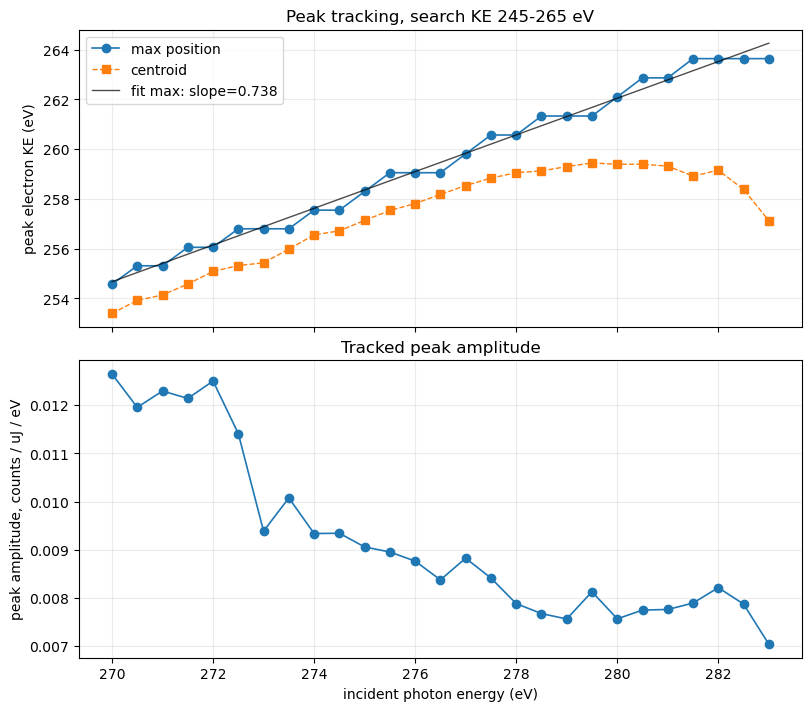

Peak tracking table:
hnu_eV    peak_KE_max    peak_KE_centroid    peak_amp
270.000      254.5698          253.3938     0.0126479
270.500      255.3096          253.9188     0.0119549
271.000      255.3096          254.1336     0.0122952
271.500      256.0524          254.5752     0.0121391
272.000      256.0524          255.0832     0.0125014
272.500      256.7980          255.3192      0.011411
273.000      256.7980          255.4278    0.00938543
273.500      256.7980          255.9804      0.010076
274.000      257.5466          256.5516    0.00933657
274.500      257.5466          256.7149     0.0093423
275.000      258.2980          257.1360     0.0090582
275.500      259.0524          257.5334     0.0089534
276.000      259.0524          257.8135    0.00876473
276.500      259.0524          258.1788    0.00837491
277.000      259.8097          258.5363    0.00882469
277.500      260.5700          258.8344    0.00841318
278.000      260.5700          259.0545    0.00788175
278.500

In [14]:
# --- Track large high-KE peak position vs incident photon energy -------

PEAK_SEARCH_KE_RANGE = (245, 265)
SMOOTH_BINS_FOR_PEAK = 5

def smooth_1d_nan(y, width):
    y = np.asarray(y, dtype=float)
    if width is None or width <= 1:
        return y

    width = int(width)
    kernel = np.ones(width, dtype=float)

    good = np.isfinite(y)
    numerator = np.convolve(np.where(good, y, 0.0), kernel, mode="same")
    denominator = np.convolve(good.astype(float), kernel, mode="same")

    out = numerator / denominator
    out[denominator <= 0] = np.nan
    return out


ke_cent_map = 0.5 * (ke_edges_map[:-1] + ke_edges_map[1:])
peak_mask = (
    np.isfinite(ke_cent_map)
    & (ke_cent_map >= PEAK_SEARCH_KE_RANGE[0])
    & (ke_cent_map <= PEAK_SEARCH_KE_RANGE[1])
)

if not peak_mask.any():
    raise ValueError(f"No KE bins inside PEAK_SEARCH_KE_RANGE={PEAK_SEARCH_KE_RANGE}")

peak_rows = []

for i, energy in enumerate(energies_map):
    y = high_map_ke[i].astype(float)
    y_s = smooth_1d_nan(y, SMOOTH_BINS_FOR_PEAK)

    x_win = ke_cent_map[peak_mask]
    y_win = y_s[peak_mask]

    good = np.isfinite(x_win) & np.isfinite(y_win)

    if np.count_nonzero(good) < 3:
        peak_rows.append((energy, np.nan, np.nan, np.nan))
        continue

    xg = x_win[good]
    yg = y_win[good]

    j = int(np.nanargmax(yg))
    peak_ke = xg[j]
    peak_amp = yg[j]

    # Simple positive-weight centroid around the search window.
    baseline = np.nanpercentile(yg, 10)
    weights = np.maximum(yg - baseline, 0.0)

    if np.nansum(weights) > 0:
        centroid = np.nansum(xg * weights) / np.nansum(weights)
    else:
        centroid = np.nan

    peak_rows.append((energy, peak_ke, centroid, peak_amp))

peak_rows = np.array(peak_rows, dtype=float)

peak_energy_axis = peak_rows[:, 0]
peak_ke = peak_rows[:, 1]
peak_centroid = peak_rows[:, 2]
peak_amp = peak_rows[:, 3]

fit_good = np.isfinite(peak_energy_axis) & np.isfinite(peak_ke)

if np.count_nonzero(fit_good) >= 2:
    coeff = np.polyfit(peak_energy_axis[fit_good], peak_ke[fit_good], deg=1)
    slope, intercept = coeff[0], coeff[1]
    fit_line = slope * peak_energy_axis + intercept
else:
    slope, intercept = np.nan, np.nan
    fit_line = np.full_like(peak_energy_axis, np.nan)

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True, constrained_layout=True)

axes[0].plot(peak_energy_axis, peak_ke, "o-", lw=1.2, label="max position")
axes[0].plot(peak_energy_axis, peak_centroid, "s--", lw=1.0, label="centroid")
axes[0].plot(
    peak_energy_axis,
    fit_line,
    "-",
    lw=1.0,
    color="k",
    alpha=0.7,
    label=f"fit max: slope={slope:.3f}",
)
axes[0].set_ylabel("peak electron KE (eV)")
axes[0].set_title(f"Peak tracking, search KE {PEAK_SEARCH_KE_RANGE[0]}-{PEAK_SEARCH_KE_RANGE[1]} eV")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(peak_energy_axis, peak_amp, "o-", lw=1.2)
axes[1].set_xlabel("incident photon energy (eV)")
axes[1].set_ylabel("peak amplitude, counts / uJ / eV")
axes[1].set_title("Tracked peak amplitude")
axes[1].grid(alpha=0.25)

plt.show()

print("Peak tracking table:")
print("hnu_eV    peak_KE_max    peak_KE_centroid    peak_amp")
for e, pk, cen, amp in peak_rows:
    print(f"{e:7.3f}  {pk:12.4f}  {cen:16.4f}  {amp:12.6g}")

print()
print(f"Linear fit to max positions: E_peak = {slope:.5f} * hnu + {intercept:.5f}")
print("Interpretation:")
print("  slope near 1 -> photoelectron-like moving feature")
print("  slope near 0 -> stationary Auger-like feature")